# Processing Workflows

While the descriptions from the first notebook are nice, they're not research data or archival metadata.

This next section details a workflow that will process your materials into a structured format that can be used for research or library systems. This is an example that can be adapted to your specific needs.

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1-wksvuqBUv8qq2mLJ8EbbluStjyvXIp7#scrollTo=OsonjvCPSjIr)  

In [9]:
import base64
from pathlib import Path 

def encode_images(image_directory: str, file_extensions: list = ['.jpg', '.png'], data_uri: bool = True):
    """Generator to encode images in the specified directory to base64 strings.
    
    Args:
        image_directory (Path): The directory containing images to encode.
        file_extensions (list, optional): List of file extensions to consider. Defaults to ['.jpg', '.png'].
        data_uri (bool, optional): If True, includes the data URI scheme in the output. Defaults to True.

    Yields:
        str: Base64 encoded string of each image.
    """
    image_directory = Path(image_directory)
    if not image_directory.is_dir():
        raise ValueError(f"The provided path {image_directory} is not a valid directory.")
    image_paths = [p for p in image_directory.iterdir() if p.suffix.lower() in file_extensions]
    for path in image_paths:
        with open(path, 'rb') as img_file:
            encoded_string = base64.b64encode(img_file.read()).decode('utf-8')
            if data_uri:
                mime_type = 'image/jpeg' if path.suffix.lower() == '.jpg' else 'image/png'
                yield f"data:{mime_type};base64,{encoded_string}"
            else:
                yield encoded_string




In [10]:
base_url = "https://glw30r2npdvyvzho.us-east-1.aws.endpoints.huggingface.cloud/v1"
api_key = "not needed for this workshop"  
model = "Qwen/Qwen3-VL-8B-Instruct"  # Qwen3-VL-8B-Instruct

In [11]:
import json
import httpx


def call_model(
    api_key: str, #your API key
    base_url: str, #API base URL
    img: str, #base64 encoded image or image URL
    prompt: str, #text prompt
    model: str = model #model name
) -> dict:
    url = f"{base_url}/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "content-type": "application/json"}
    data = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": img}},
                    {"type": "text", "text": prompt},
                ],
            }
        ],
    }
    try:
        response = httpx.post(url, headers=headers, json=data)

        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
        try:
            response_data = response.json()
        except json.JSONDecodeError:
            print("Error decoding JSON response")
            return {"error": "Failed to decode JSON response"}
        if response_data.get("choices", None):
            return response_data["choices"][0]["message"]["content"]
        else:
            print("Error: No choices in response")
            return {"error": "No choices in response"}
    except httpx.RequestError as e:
        print("Request error:", str(e))
        return {"error": str(e)}    

## Code tags 

AI models often add code tags (```) around code snippets. These should be removed for cleaner presentation.

a common pattern is:
```
```yaml
# some text here
``````

In [107]:
import re


def remove_code_tags(text):
    """Remove code tags (triple backticks) from the text. Also remove tags with language specifiers such as ```yaml."""
    return re.sub(r"```[a-zA-Z]*\n(.*?)\n```", r"\1", text, flags=re.DOTALL)


print(remove_code_tags("Here is some code:\n```python\nprint('Hello, World!')\n```"))

Here is some code:
print('Hello, World!')

## Remove ‘hiccups’ 

Another common issue with LLMs is repeated text or 'hiccups' in the output. For example, a model might repeat a phrase or sentence multiple times unnecessarily. This is usually because the model was told to generate a certain length of text and it fills in the space with repeated content.

In [ ]:
import re


def remove_repeated_phrases(text):
    """Remove repeated phrases in the text."""
    # This regex looks for any phrase (sequence of words) that is repeated consecutively
    pattern = r"(\b\w+(?: \w+){0,5}\b)( \1)+"
    return re.sub(pattern, r"\1", text)


print(
    remove_repeated_phrases(
        "This is a test test test of the function function function."
    )
)

1. download the images from IIIF to a folder
2. add other relevant images to the folder

# Image-level Processing
- Input is the URL for a box manifest in EAP (or other IIIF collection)
- We need to recognize the relevant entities (people, places, organizations) in each item in the context of the larger collection. For a legal case, for example, we only need entities in the case as well as their relationship to the case (e.g. plaintiff, judge, victim).

# Item-level Processing

- Extract the text of all individual images
- Use text and descriptions to predict individual items (a two-page letter, a 50-page memo...)
- Generate item-level research metadata

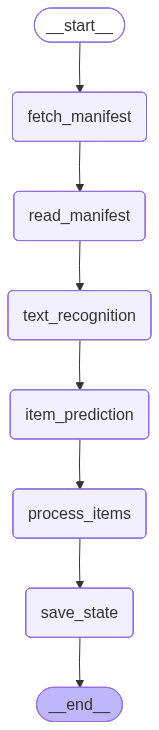

In [39]:
from IPython.display import Image as IPythonImage

display(IPythonImage(graph.get_graph().draw_mermaid_png()))

# State

As we move from step to step in the workflow, we will need something to store the data from prior steps and to make that data available. This object is often called "state" in programming. In the cell below, we create a simple state object to hold our data as we move through the workflow.

Given that we're processing a box of archival materials, I have called it "Box." I find it helpful to think of the fields in the object as columns in a spreadsheet. Each field (box_manifest_uri, image_uris...) gives us a placeholder for information that we'd like to gather during the workflow. How you design your state object can be helpful in deciding what steps are needed in the workflow and what your final output should look like.

In [90]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining
# https://typing.python.org/en/latest/spec/typeddict.html

from typing_extensions import TypedDict


class Box(TypedDict):  # Level: File in EAP
    box_manifest_uri: str
    box_manifest_data: dict
    box_metadata: dict
    box_summary: str
    image_urls: list[str]
    image_height: int
    image_width: int
    images: list[dict]
    item_grouping: list
    items: dict
    image_descriptions: bool
    start_index: int  # Start processing from this image index
    end_index: int  # End processing at this image index

# Steps in the Workflow

In [ ]:
import json
from streamlit import image
from tqdm import tqdm
from rich import print
from pathlib import Path

# https://docs.langchain.com/oss/python/langgraph/workflows-agents


# Steps
def load_manifest(state: Box) -> Box:
    manifest = Path('manifest.json')
    # load json file 
    with open(manifest) as f:
        manifest = json.load(f)
    metadata = {}
    for item in manifest["metadata"]:
        metadata[item["label"]] = item["value"]
    return {
        "box_metadata": metadata,
    }


def text_recognition(state: Box) -> Box:
    """Extract text from images using OCR."""
    images = encode_images("img")
    metadata = state["box_metadata"]
    for image in tqdm(images, desc="Extracting text from images"):
        
        response = call_model(
            api_key=api_key,
            base_url=base_url,
            img=image,
            prompt=f"Extract and return all the text from this image as markdown. {'Metadata about the image:' + str(metadata) if metadata else ''} Include all text elements and maintain the reading order.",
        )
        image["markdown_text"] = response
    return state


def save_state(state: Box) -> Box:
    box_id = (
        state["box_metadata"]
        .get("Identifier", "unknown_box")
        .replace(" ", "_")
        .replace("/", "_")
    )
    # if not output directory, create it
    import os

    os.makedirs("output", exist_ok=True)
    with open(f"output/{box_id}.json", "w") as f:
        json.dump(state, f, indent=4)
    print(f"Saved processed state to output/{box_id}.json")
    return state

In [92]:
from langgraph.graph import StateGraph, START, END


# Build workflow
builder = StateGraph(Box)

# Add nodes
builder.add_node("fetch_manifest", fetch_manifest)
builder.add_node("read_manifest", read_manifest)
builder.add_node("text_recognition", text_recognition)
builder.add_node("save_state", save_state)

# Add edges to connect nodes
builder.add_edge(START, "fetch_manifest")
builder.add_edge("fetch_manifest", "read_manifest")
builder.add_edge("read_manifest", "text_recognition")
builder.add_edge("text_recognition", "save_state")
builder.add_edge("save_state", END)

# Compile
graph = builder.compile()

In [97]:
# Invoke

output = graph.invoke(
    {
        "box_manifest_uri": "https://eap.bl.uk/archive-file/EAP532-2-1-1/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP532-2-1-1/manifest",
        "end_index": 10,  # process no more than 10 images
    }
)

Successfully fetched manifest for Circular to Northern Education Advisory NEAC Meeting [1957]

Found 10 images in manifest

Extracting text from images:   0%|          | 0/10 [00:00<?, ?it/s]

Request error: The read operation timed out

Extracting text from images:  10%|█         | 1/10 [00:10<01:34, 10.51s/it]


KeyboardInterrupt: 

In [63]:
from rich import print

for item in output["images"]:
    print(item)

{
    'image_url': 'https://images.eap.bl.uk/EAP699/EAP699_23_1/1.jp2/full/full/0/default.jpg',
    'markdown_text': '```markdown\nMoldova, Europe\n\nPhotographs\n\nBritish Library, EAP699/23/1, 
https://eap.bl.uk/archive-file/EAP699-23-1\n\nDigitised by: Institute of the Cultural Heritage of the Academy of 
Sciences of Moldova\n\nDigitisation funded by: Endangered Archives Programme supported by Arcadia\n\nLanguage: 
Romanian, Russian\n\nScripts: Cyrillic, Latin\n```'
}

{
    'image_url': 'https://images.eap.bl.uk/EAP699/EAP699_23_1/2.jp2/full/full/0/default.jpg',
    'markdown_text': 'There is no text present in the image. The image is a vintage, sepia-toned photograph of a 
group of people, likely from the 1970s or 1980s, arranged in rows for a formal group portrait. The photograph shows
signs of aging, such as creases, cracks, and discoloration, but no written text or labels are visible within the 
image itself.\n\nThe metadata provided describes the image as part of the British Library’s Endangered Archives 
Programme collection, but this information is not part of the visual content of the photograph.'
}

{
    'image_url': 'https://images.eap.bl.uk/EAP699/EAP699_23_1/3.jp2/full/full/0/default.jpg',
    'markdown_text': 'There is no text in the image.'
}

{
    'image_url': 'https://images.eap.bl.uk/EAP699/EAP699_23_1/4.jp2/full/full/0/default.jpg',
    'markdown_text': 'There is no text in the image.'
}

## For evaluation section

In [44]:
import srsly 
evaluation_data = srsly.read_json("fmb_evaluation_data.json")

In [45]:
# Get manifest URIs from evaluation data
manifest_uris = [entry["manifest_uri"] for entry in evaluation_data.values()]
len(manifest_uris)

37

In [65]:
from pathlib import Path
for manifest in manifest_uris[9:10]:
    print(f"Processing manifest: {manifest}")
    if Path("output/" + manifest.split("/")[-2].replace("-", "_") + ".json").exists():
        print(f"Skipping {manifest}, already processed.")
        continue
    output = graph.invoke(
        {
            "box_manifest_uri": manifest,
            "start_index": 0,
            #end_index": 3,
            "image_width": 400,
        }
    )

Processing manifest: https://eap.bl.uk/archive-file/EAP1477-1-1-10/manifest

Successfully fetched manifest for Caja 10

Found 2011 images in manifest

Extracting text from images:   0%|          | 6/2011 [00:19<1:51:49,  3.35s/it]

Request error: The read operation timed out

...

Request error: The read operation timed out

Extracting text from images:   0%|          | 10/2011 [00:48<3:39:32,  6.58s/it]

Request error: The read operation timed out

Extracting text from images:   1%|          | 11/2011 [01:00<3:03:07,  5.49s/it]


KeyboardInterrupt: 